# 08 – Hyperparameter-Tuning und Kalibrierung

## Ziel

Dieses Notebook dokumentiert die bereits abgeschlossene Modellauswahl für h4, h16 und h96. Es startet keine neuen Trials und öffnet keinen finalen Testsplit.

Es beantwortet:

- Welche LightGBM- und CatBoost-Konfigurationen wurden ausgewählt?
- Wie gut und stabil waren die Walk-Forward-CV-Ergebnisse?
- Wie verhielt sich die einmalige Holdout-Bestätigung?
- Welche Kalibrierungsmethode wurde je Modell und Horizont gewählt?
- Welche Modell-/Kalibrierungskombination wurde für die wirtschaftliche Analyse eingefroren?

> **Version 1.0.2:** Tuningberichte werden pro **Horizont und Modell** ausgewählt. Kalibrierungsberichte ohne eigenes `horizon`-Feld werden über ihre referenzierte Tuningdatei zugeordnet. Falls keine Kalibrierungsdatei auffindbar ist, dient `reports/final/horizon_comparison.csv` als rein deskriptiver Fallback.

## 1. Umgebung und Projektroot

In [27]:
from __future__ import annotations

import json
import os
import sys
from collections import defaultdict
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

NOTEBOOK_VERSION = "1.0.2"
EXPECTED_HORIZONS = (4, 16, 96)
EXPECTED_MODELS = ("lightgbm", "catboost")


def find_project_root() -> Path:
    override = os.environ.get("BTC_PROJECT_ROOT")
    candidates: list[Path] = []
    if override:
        candidates.append(Path(override).expanduser())
    current = Path.cwd()
    candidates.extend([current, *current.parents])

    seen: set[Path] = set()
    for candidate in candidates:
        absolute = Path(os.path.abspath(os.fspath(candidate)))
        if absolute in seen:
            continue
        seen.add(absolute)
        if (absolute / "reports").is_dir() and (
            (absolute / "config.py").exists()
            or (absolute / "final_project_report.py").exists()
            or (absolute / "reports" / "final").exists()
        ):
            return absolute
    raise FileNotFoundError(
        "Projektroot nicht gefunden. Setze BTC_PROJECT_ROOT auf den Ordner 'BTC TSP 15min'."
    )


PROJECT_ROOT = find_project_root()
REPORTS_DIR = PROJECT_ROOT / "reports"
FINAL_REPORT_DIR = REPORTS_DIR / "final"

print(f"Notebook-Version: {NOTEBOOK_VERSION}")
print(f"Projektroot:      {PROJECT_ROOT}")
print(f"Reports:          {REPORTS_DIR}")

Notebook-Version: 1.0.2
Projektroot:      /home/milan/uni/python/BTC TSP/BTC TSP 15min
Reports:          /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports


## 2. Artefakterkennung pro Horizont **und Modell**

h4 wurde in getrennten LightGBM- und CatBoost-Läufen optimiert. Deshalb reicht „neuester Bericht pro Horizont“ nicht aus. Die korrigierte Logik wählt den geeigneten Bericht für jedes Paar:

```text
(h4, LightGBM)
(h4, CatBoost)
(h16, LightGBM)
...
```

Bevorzugt werden Pfade aus `reports/final/source_runs.json` und aus den gespeicherten Kalibrierungsberichten. Fehlende Modellquellen werden durch die globale Reportsuche ergänzt.

In [28]:
def read_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        raise TypeError(f"JSON-Objekt erwartet: {path}")
    return payload


def existing_path(value: str | Path) -> Path | None:
    path = Path(value).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    path = Path(os.path.abspath(os.fspath(path)))
    return path if path.is_file() else None


def recursive_strings(value: Any) -> Iterable[str]:
    if isinstance(value, dict):
        for item in value.values():
            yield from recursive_strings(item)
    elif isinstance(value, list):
        for item in value:
            yield from recursive_strings(item)
    elif isinstance(value, str):
        yield value


def horizon_from_text(value: Any) -> int | None:
    if value is None:
        return None
    text = str(value).lower().replace("-", "_")
    # Längere Horizonte zuerst prüfen.
    for horizon in (96, 16, 4):
        markers = (
            f"_h{horizon}",
            f"h{horizon}_",
            f"binary_h{horizon}",
            f"binary_{horizon}",
            f"target_binary_{horizon}",
            f"target_end_time_{horizon}",
            f"target_return_{horizon}",
        )
        if any(marker in text for marker in markers):
            return horizon
    return None


def infer_horizon(payload: dict[str, Any], path: Path) -> int | None:
    for key in ("horizon", "target_horizon", "prediction_horizon"):
        value = payload.get(key)
        try:
            if value is not None:
                return int(value)
        except (TypeError, ValueError):
            pass

    # Nicht nur Top-Level-Felder prüfen: selected_calibration.json enthält
    # den Horizont bei h4 häufig nur indirekt über Parameter-/Quellpfade.
    direct_candidates = [
        payload.get("target_column"),
        payload.get("target_end_time_column"),
        payload.get("split_name"),
        payload.get("report_dir"),
        path,
    ]
    for candidate in [*direct_candidates, *recursive_strings(payload)]:
        horizon = horizon_from_text(candidate)
        if horizon is not None:
            return horizon
    return None


def models_in_tuning_summary(payload: dict[str, Any]) -> set[str]:
    models: set[str] = set()
    summaries = payload.get("model_summaries", [])
    if isinstance(summaries, list):
        for item in summaries:
            if isinstance(item, dict) and item.get("model"):
                models.add(str(item["model"]).lower())
    if not models and payload.get("selected_model"):
        models.add(str(payload["selected_model"]).lower())
    return models


def referenced_paths_from_final_report() -> tuple[set[Path], set[Path]]:
    tuning: set[Path] = set()
    calibration: set[Path] = set()
    source_path = FINAL_REPORT_DIR / "source_runs.json"
    if not source_path.is_file():
        return tuning, calibration
    payload = read_json(source_path)
    for raw in recursive_strings(payload):
        if raw.endswith("hyperparameter_tuning_summary.json"):
            path = existing_path(raw)
            if path:
                tuning.add(path)
        elif raw.endswith(("selected_calibration.json", "calibration_selection.json")):
            path = existing_path(raw)
            if path:
                calibration.add(path)
    return tuning, calibration


def local_equivalent_source(raw: str, candidates: Iterable[Path]) -> Path | None:
    """Findet eine verschobene Quell-Datei anhand des Run-Ordners."""
    source = Path(raw)
    parent_name = source.parent.name
    if not parent_name:
        return None
    matches = [
        candidate
        for candidate in candidates
        if candidate.parent.name == parent_name
    ]
    if not matches:
        return None
    return max(matches, key=lambda item: item.stat().st_mtime)


def infer_calibration_horizon(
    payload: dict[str, Any],
    path: Path,
    tuning_candidates: Iterable[Path],
) -> int | None:
    horizon = infer_horizon(payload, path)
    if horizon is not None:
        return horizon

    for raw in recursive_strings(payload):
        if not raw.endswith("hyperparameter_tuning_summary.json"):
            continue
        tuning_path = existing_path(raw)
        if tuning_path is None:
            tuning_path = local_equivalent_source(raw, tuning_candidates)
        if tuning_path is None:
            continue
        try:
            tuning_payload = read_json(tuning_path)
        except Exception:
            continue
        horizon = infer_horizon(tuning_payload, tuning_path)
        if horizon is not None:
            return horizon
    return None


def newest_calibration_per_horizon(
    paths: Iterable[Path],
    tuning_candidates: Iterable[Path],
) -> dict[int, Path]:
    grouped: dict[int, list[Path]] = defaultdict(list)
    for path in set(paths):
        try:
            payload = read_json(path)
        except Exception:
            continue
        horizon = infer_calibration_horizon(
            payload,
            path,
            tuning_candidates,
        )
        if horizon is not None:
            grouped[horizon].append(path)
    return {
        horizon: max(items, key=lambda item: item.stat().st_mtime)
        for horizon, items in grouped.items()
    }


referenced_tuning, referenced_calibration = referenced_paths_from_final_report()
all_tuning = set(REPORTS_DIR.glob("**/hyperparameter_tuning_summary.json"))
all_calibration = set(REPORTS_DIR.glob("**/selected_calibration.json"))
all_calibration |= set(REPORTS_DIR.glob("**/calibration_selection.json"))

# Zuerst alle Tuningquellen sammeln, damit Kalibrierungen ohne eigenes
# horizon-Feld über parameter_source.source_path zugeordnet werden können.
tuning_candidates_initial = referenced_tuning | all_tuning
calibration_paths = newest_calibration_per_horizon(
    referenced_calibration | all_calibration,
    tuning_candidates_initial,
)

# Tuningquellen, die direkt in der Kalibrierung dokumentiert wurden.
calibration_tuning_refs: set[Path] = set()
for calibration_path in calibration_paths.values():
    payload = read_json(calibration_path)
    for raw in recursive_strings(payload):
        if raw.endswith("hyperparameter_tuning_summary.json"):
            source = existing_path(raw)
            if source is None:
                source = local_equivalent_source(raw, all_tuning)
            if source:
                calibration_tuning_refs.add(source)

tuning_candidates = referenced_tuning | calibration_tuning_refs | all_tuning
priority_paths = referenced_tuning | calibration_tuning_refs

# Auswahl pro (Horizont, Modell), nicht nur pro Horizont.
tuning_model_sources: dict[tuple[int, str], Path] = {}
tuning_source_priority: dict[tuple[int, str], tuple[int, float]] = {}

for path in tuning_candidates:
    try:
        payload = read_json(path)
    except Exception:
        continue
    horizon = infer_horizon(payload, path)
    if horizon is None:
        continue
    for model in models_in_tuning_summary(payload):
        key = (horizon, model)
        score = (1 if path in priority_paths else 0, path.stat().st_mtime)
        if key not in tuning_source_priority or score > tuning_source_priority[key]:
            tuning_source_priority[key] = score
            tuning_model_sources[key] = path

# Rein deskriptiver Fallback für die Kalibrierungsauswahl.
final_calibration_fallbacks: dict[int, dict[str, Any]] = {}
horizon_comparison_path = FINAL_REPORT_DIR / "horizon_comparison.csv"
if horizon_comparison_path.is_file():
    try:
        final_horizon_table = pd.read_csv(horizon_comparison_path)
    except pd.errors.EmptyDataError:
        final_horizon_table = pd.DataFrame()
    if "horizon" in final_horizon_table:
        for _, row in final_horizon_table.iterrows():
            try:
                horizon = int(row["horizon"])
            except (TypeError, ValueError):
                continue
            final_calibration_fallbacks[horizon] = {
                "horizon": horizon,
                "selected_model": row.get("selected_model"),
                "selected_calibration_method": row.get("calibration_method"),
                "selection_metric": "log_loss",
                "metric_mean": row.get("calibration_metric_mean"),
                "metric_std": row.get("calibration_metric_std"),
                "stability_score": np.nan,
                "selection_source": "reports/final/horizon_comparison.csv (deskriptiver Fallback)",
                "holdout_used_for_selection": False,
                "test_used_for_selection": False,
                "selected_method_per_model": "{}",
                "source_path": str(horizon_comparison_path),
                "source_kind": "final_report_fallback",
            }

available_horizons = sorted(
    set(h for h, _ in tuning_model_sources)
    | set(calibration_paths)
    | set(final_calibration_fallbacks)
)

source_rows = []
for horizon in sorted(set(EXPECTED_HORIZONS) | set(available_horizons)):
    for model in EXPECTED_MODELS:
        path = tuning_model_sources.get((horizon, model))
        calibration_path = calibration_paths.get(horizon)
        fallback = final_calibration_fallbacks.get(horizon)
        source_rows.append({
            "horizon": horizon,
            "model": model,
            "tuning_found": path is not None,
            "tuning_summary": str(path or ""),
            "calibration_found": calibration_path is not None or fallback is not None,
            "calibration_source_kind": (
                "selected_calibration.json"
                if calibration_path is not None
                else "final_report_fallback"
                if fallback is not None
                else "missing"
            ),
            "selected_calibration": str(
                calibration_path
                or (horizon_comparison_path if fallback is not None else "")
            ),
        })

artifact_overview = pd.DataFrame(source_rows)
display(artifact_overview)

missing_sources = artifact_overview.loc[
    ~artifact_overview["tuning_found"], ["horizon", "model"]
]
if not missing_sources.empty:
    display(Markdown(
        "> **Hinweis:** Für diese Kombinationen wurde kein Tuningbericht gefunden: "
        + ", ".join(
            f"h{int(row.horizon)} {row.model}"
            for row in missing_sources.itertuples()
        )
    ))

missing_calibrations = sorted(
    set(EXPECTED_HORIZONS)
    - set(calibration_paths)
    - set(final_calibration_fallbacks)
)
if missing_calibrations:
    display(Markdown(
        "> **Hinweis:** Keine Kalibrierungsquelle gefunden für: "
        + ", ".join(f"h{h}" for h in missing_calibrations)
    ))


,horizon,model,tuning_found,tuning_summary,calibration_found,calibration_source_kind,selected_calibration
0,4,lightgbm,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260728T212206/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selected_calibration.json
1,4,catboost,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260729T075025/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selected_calibration.json
2,16,lightgbm,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T024005/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selected_calibration.json
3,16,catboost,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T024005/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selected_calibration.json
4,96,lightgbm,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T080237/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/calibration/selected_calibration.json
5,96,catboost,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T080237/hyperparameter_tuning_summary.json,True,selected_calibration.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/calibration/selected_calibration.json


## 3. Sicherheitsprüfung

In [29]:
def true_flags(value: Any, prefix: str = "") -> list[str]:
    found: list[str] = []
    if isinstance(value, dict):
        for key, item in value.items():
            name = f"{prefix}.{key}" if prefix else str(key)
            if isinstance(item, bool) and item:
                found.append(name)
            else:
                found.extend(true_flags(item, name))
    elif isinstance(value, list):
        for index, item in enumerate(value):
            found.extend(true_flags(item, f"{prefix}[{index}]"))
    return found

FORBIDDEN_SUFFIXES = (
    "test_evaluated", "test_used_for_tuning", "test_used_for_selection",
    "final_test_accessed", "holdout_test_accessed",
)

security_errors: list[str] = []
all_paths = set(tuning_model_sources.values()) | set(calibration_paths.values())
for path in all_paths:
    payload = read_json(path)
    for flag in true_flags(payload):
        if flag.endswith(FORBIDDEN_SUFFIXES):
            security_errors.append(f"{path}: {flag}=true")

if security_errors:
    raise RuntimeError("Sicherheitsprüfung fehlgeschlagen:\n- " + "\n- ".join(security_errors))
print("Sicherheitsprüfung bestanden: kein finaler Testzugriff gemeldet.")

Sicherheitsprüfung bestanden: kein finaler Testzugriff gemeldet.


## 4. Tuning-Ergebnisse normalisieren

In [30]:
tuning_rows: list[dict[str, Any]] = []
parameter_rows: list[dict[str, Any]] = []

# Ein Bericht kann mehrere Modelle enthalten. Es wird nur der Modellblock
# übernommen, für den dieser Pfad als Quelle ausgewählt wurde.
for (horizon, selected_model), selected_path in sorted(tuning_model_sources.items()):
    payload = read_json(selected_path)
    summaries = payload.get("model_summaries", [])
    if not isinstance(summaries, list):
        continue
    for item in summaries:
        if not isinstance(item, dict):
            continue
        model = str(item.get("model", "")).lower()
        if model != selected_model:
            continue
        parameters = item.get("best_parameters", {})
        if not isinstance(parameters, dict):
            parameters = {}
        tuning_rows.append({
            "horizon": horizon,
            "horizon_hours": horizon * 0.25,
            "model": model,
            "selected_by_tuning": model == str(payload.get("selected_model", "")).lower(),
            "cv_log_loss_mean": item.get("best_metric_mean"),
            "cv_log_loss_std": item.get("best_metric_std"),
            "stability_objective": item.get("best_objective_value"),
            "holdout_log_loss": item.get("holdout_metric_value"),
            "requested_trials": item.get("requested_trial_budget"),
            "completed_trials": item.get("completed_trials"),
            "pruned_trials": item.get("pruned_trials"),
            "failed_trials": item.get("failed_trials"),
            "best_trial_number": item.get("best_trial_number"),
            "source_path": str(selected_path),
        })
        for parameter, value in parameters.items():
            parameter_rows.append({
                "horizon": horizon,
                "model": model,
                "parameter": parameter,
                "value": value,
                "source_path": str(selected_path),
            })

tuning_table = pd.DataFrame(tuning_rows)
parameter_table = pd.DataFrame(parameter_rows)

for column in (
    "cv_log_loss_mean", "cv_log_loss_std", "stability_objective",
    "holdout_log_loss", "requested_trials", "completed_trials",
    "pruned_trials", "failed_trials", "best_trial_number",
):
    if column in tuning_table:
        tuning_table[column] = pd.to_numeric(tuning_table[column], errors="coerce")

if tuning_table.empty:
    raise RuntimeError("Keine Modellmetriken aus den Tuningberichten extrahiert.")

# Eindeutigkeit ist entscheidend: genau eine Zeile je Horizont und Modell.
duplicates = tuning_table.duplicated(["horizon", "model"], keep=False)
if duplicates.any():
    display(tuning_table.loc[duplicates].sort_values(["horizon", "model"]))
    raise RuntimeError("Doppelte Tuningzeilen je Horizont/Modell erkannt.")

display(tuning_table.sort_values(["horizon", "model"]).reset_index(drop=True))

,horizon,horizon_hours,model,selected_by_tuning,cv_log_loss_mean,cv_log_loss_std,stability_objective,holdout_log_loss,requested_trials,completed_trials,pruned_trials,failed_trials,best_trial_number,source_path
0,4,1.000000,catboost,True,0.598105,0.035227,0.606912,0.770911,100,43,57,0,67,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260729T075025/hyperparameter_tuning_summary.json
1,4,1.000000,lightgbm,True,0.597973,0.035088,0.606745,0.658740,100,56,44,0,31,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260728T212206/hyperparameter_tuning_summary.json
2,16,4.000000,catboost,True,0.672113,0.006467,0.673729,0.696889,25,6,19,0,2,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T024005/hyperparameter_tuning_summary.json
3,16,4.000000,lightgbm,False,0.677126,0.002509,0.677753,0.683636,25,20,5,0,6,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T024005/hyperparameter_tuning_summary.json
4,96,24.000000,catboost,True,0.693591,0.001188,0.693888,0.693516,25,17,8,0,18,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T080237/hyperparameter_tuning_summary.json
5,96,24.000000,lightgbm,False,0.693615,0.001246,0.693926,0.694373,25,17,8,0,10,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T080237/hyperparameter_tuning_summary.json


## 5. Cross-Validation-Leistung

Für `log_loss` gilt: kleiner ist besser. Fehlende Kombinationen werden als Text ausgewiesen statt als scheinbar leerer Balken.

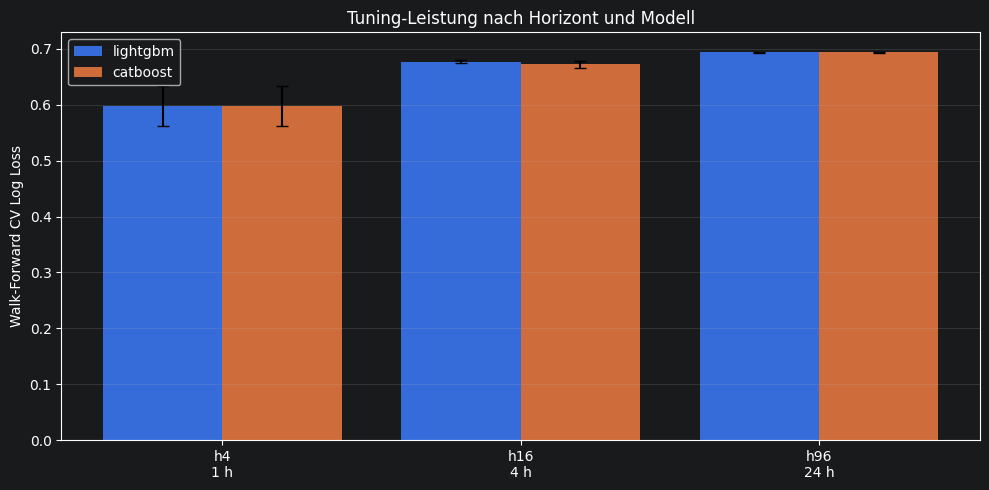

h4 LightGBM erfolgreich geladen: CV Log Loss = 0.597973


In [31]:
plot_data = tuning_table.dropna(subset=["cv_log_loss_mean"]).copy()
models = list(EXPECTED_MODELS)
horizons = sorted(set(EXPECTED_HORIZONS) | set(plot_data["horizon"].astype(int)))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(horizons))
width = 0.8 / len(models)

for model_index, model in enumerate(models):
    rows = plot_data[plot_data["model"] == model].set_index("horizon").reindex(horizons)
    offsets = x - 0.4 + width / 2 + model_index * width
    values = rows["cv_log_loss_mean"].to_numpy(dtype=float)
    errors = rows["cv_log_loss_std"].fillna(0.0).to_numpy(dtype=float)
    present = np.isfinite(values)
    ax.bar(offsets[present], values[present], width=width, yerr=errors[present], capsize=4, label=model)
    for position, is_present in zip(offsets, present):
        if not is_present:
            ax.text(position, 0.01, "fehlt", ha="center", va="bottom", rotation=90, transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels([f"h{h}\n{h * 15 / 60:g} h" for h in horizons])
ax.set_ylabel("Walk-Forward CV Log Loss")
ax.set_title("Tuning-Leistung nach Horizont und Modell")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Direkte Kontrolle der zuvor problematischen Zelle.
h4_lightgbm = tuning_table[(tuning_table["horizon"] == 4) & (tuning_table["model"] == "lightgbm")]
if h4_lightgbm.empty or h4_lightgbm["cv_log_loss_mean"].isna().all():
    display(Markdown("> ⚠️ **h4 LightGBM fehlt weiterhin.** Prüfe die in Abschnitt 2 angezeigten Quellpfade."))
else:
    value = float(h4_lightgbm.iloc[0]["cv_log_loss_mean"])
    print(f"h4 LightGBM erfolgreich geladen: CV Log Loss = {value:.6f}")

## 6. Stabilität und Holdout-Bestätigung

In [32]:
ranking_rows = []
for horizon, group in tuning_table.groupby("horizon"):
    ranked = group.dropna(subset=["cv_log_loss_mean"]).sort_values("cv_log_loss_mean")
    if ranked.empty:
        continue
    best = ranked.iloc[0]
    second = ranked.iloc[1] if len(ranked) > 1 else None
    holdout = group.dropna(subset=["holdout_log_loss"]).sort_values("holdout_log_loss")
    ranking_rows.append({
        "horizon": int(horizon),
        "cv_winner": best["model"],
        "cv_winner_log_loss": best["cv_log_loss_mean"],
        "cv_margin_to_second": second["cv_log_loss_mean"] - best["cv_log_loss_mean"] if second is not None else np.nan,
        "cv_winner_std": best["cv_log_loss_std"],
        "holdout_winner": holdout.iloc[0]["model"] if not holdout.empty else None,
        "holdout_winner_log_loss": holdout.iloc[0]["holdout_log_loss"] if not holdout.empty else np.nan,
        "ranking_agrees": bool(not holdout.empty and holdout.iloc[0]["model"] == best["model"]),
    })
ranking_table = pd.DataFrame(ranking_rows)
display(ranking_table.sort_values("horizon"))

,horizon,cv_winner,cv_winner_log_loss,cv_margin_to_second,cv_winner_std,holdout_winner,holdout_winner_log_loss,ranking_agrees
0,4,lightgbm,0.597973,0.000133,0.035088,lightgbm,0.658740,True
1,16,catboost,0.672113,0.005013,0.006467,lightgbm,0.683636,False
2,96,catboost,0.693591,0.000024,0.001188,catboost,0.693516,True


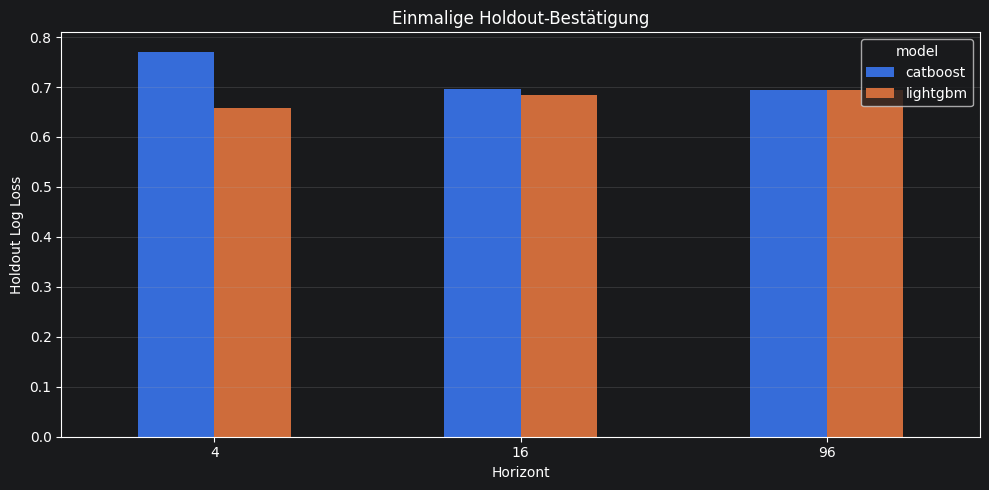

In [33]:
holdout_data = tuning_table.dropna(subset=["holdout_log_loss"]).copy()
if holdout_data.empty:
    print("Keine Holdout-Metriken vorhanden.")
else:
    pivot = holdout_data.pivot(index="horizon", columns="model", values="holdout_log_loss").sort_index()
    axis = pivot.plot(kind="bar", figsize=(10, 5), rot=0)
    axis.set_title("Einmalige Holdout-Bestätigung")
    axis.set_xlabel("Horizont")
    axis.set_ylabel("Holdout Log Loss")
    axis.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Trialstatus

,horizon,model,requested_trials,completed_trials,pruned_trials,failed_trials,best_trial_number
0,4,catboost,100,43,57,0,67
1,4,lightgbm,100,56,44,0,31
2,16,catboost,25,6,19,0,2
3,16,lightgbm,25,20,5,0,6
4,96,catboost,25,17,8,0,18
5,96,lightgbm,25,17,8,0,10


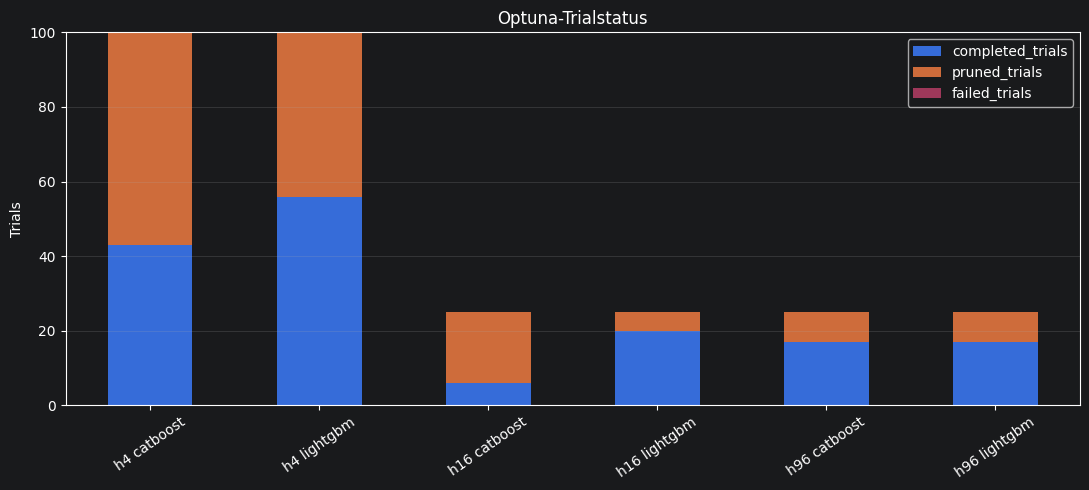

In [34]:
trial_view = tuning_table[[
    "horizon", "model", "requested_trials", "completed_trials",
    "pruned_trials", "failed_trials", "best_trial_number"
]].sort_values(["horizon", "model"])
display(trial_view)

plot = trial_view.dropna(subset=["completed_trials", "pruned_trials"]).copy()
if not plot.empty:
    plot["label"] = "h" + plot["horizon"].astype(int).astype(str) + " " + plot["model"]
    axis = plot.set_index("label")[["completed_trials", "pruned_trials", "failed_trials"]].fillna(0).plot(
        kind="bar", stacked=True, figsize=(11, 5), rot=35
    )
    axis.set_title("Optuna-Trialstatus")
    axis.set_xlabel("")
    axis.set_ylabel("Trials")
    axis.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Ausgewählte Hyperparameter

In [35]:
if parameter_table.empty:
    print("Keine Hyperparameter gefunden.")
else:
    for (horizon, model), group in parameter_table.groupby(["horizon", "model"], sort=True):
        display(Markdown(f"### h{int(horizon)} · {model}"))
        display(group[["parameter", "value"]].sort_values("parameter").reset_index(drop=True))

### h4 · catboost

,parameter,value
0,bootstrap_type,Bernoulli
1,border_count,128
2,depth,5
3,iterations,1600
4,l2_leaf_reg,0.182427
5,leaf_estimation_iterations,5
6,learning_rate,0.011318
7,random_strength,0.000011
8,rsm,0.578784
9,subsample,0.569511


### h4 · lightgbm

,parameter,value
0,colsample_bytree,0.664128
1,learning_rate,0.006265
2,max_bin,127
3,max_depth,12
4,min_child_samples,90
5,min_split_gain,0.551715
6,n_estimators,1400
7,num_leaves,18
8,reg_alpha,0.038682
9,reg_lambda,8.559443


### h16 · catboost

...

,parameter,value
0,colsample_bytree,0.655458
1,learning_rate,0.010158
2,max_bin,255
3,max_depth,6
4,min_child_samples,32
5,min_split_gain,0.006156
6,n_estimators,500
7,num_leaves,15
8,reg_alpha,0.217515
9,reg_lambda,0.025959


### h96 · catboost

,parameter,value
0,bagging_temperature,3.345697
1,bootstrap_type,Bayesian
2,border_count,128
3,depth,6
4,iterations,1100
5,l2_leaf_reg,0.497553
6,leaf_estimation_iterations,5
7,learning_rate,0.025831
8,random_strength,0.099619
9,rsm,0.945617


### h96 · lightgbm

,parameter,value
0,colsample_bytree,0.740274
1,learning_rate,0.021528
2,max_bin,255
3,max_depth,6
4,min_child_samples,206
5,min_split_gain,0.006156
6,n_estimators,1100
7,num_leaves,110
8,reg_alpha,1.785832
9,reg_lambda,0.759715


## 9. Kalibrierungsauswahl

In [36]:
CALIBRATION_COLUMNS = [
    "horizon",
    "selected_model",
    "selected_calibration_method",
    "selection_metric",
    "metric_mean",
    "metric_std",
    "stability_score",
    "selection_source",
    "holdout_used_for_selection",
    "test_used_for_selection",
    "selected_method_per_model",
    "source_path",
    "source_kind",
]

calibration_rows: list[dict[str, Any]] = []
for horizon, path in sorted(calibration_paths.items()):
    payload = read_json(path)
    calibration_rows.append({
        "horizon": horizon,
        "selected_model": payload.get("selected_model"),
        "selected_calibration_method": payload.get(
            "selected_calibration_method",
            payload.get("selected_method", payload.get("calibration_method")),
        ),
        "selection_metric": payload.get("selection_metric"),
        "metric_mean": payload.get("metric_mean", payload.get("selected_metric_mean")),
        "metric_std": payload.get("metric_std", payload.get("selected_metric_std")),
        "stability_score": payload.get("stability_score", payload.get("selected_score")),
        "selection_source": payload.get("selection_source", "walk_forward_cv_only"),
        "holdout_used_for_selection": payload.get("holdout_used_for_selection", False),
        "test_used_for_selection": payload.get("test_used_for_selection", False),
        "selected_method_per_model": json.dumps(
            payload.get("selected_method_per_model", {}),
            ensure_ascii=False,
            sort_keys=True,
        ),
        "source_path": str(path),
        "source_kind": "selected_calibration_json",
    })

# Fehlende Horizonte ausschließlich deskriptiv aus dem finalen Aggregat ergänzen.
loaded_horizons = {int(row["horizon"]) for row in calibration_rows}
for horizon, fallback in sorted(final_calibration_fallbacks.items()):
    if horizon not in loaded_horizons:
        calibration_rows.append(dict(fallback))

# Explizite Spalten verhindern KeyError auch dann, wenn keinerlei Quelle vorliegt.
calibration_table = pd.DataFrame(
    calibration_rows,
    columns=CALIBRATION_COLUMNS,
)

for column in ("metric_mean", "metric_std", "stability_score"):
    calibration_table[column] = pd.to_numeric(
        calibration_table[column],
        errors="coerce",
    )

if calibration_table.empty:
    display(Markdown(
        "> **Keine Kalibrierungsartefakte gefunden.** Geprüft wurden "
        "`reports/**/selected_calibration.json`, "
        "`reports/**/calibration_selection.json` und "
        "`reports/final/horizon_comparison.csv`."
    ))
else:
    display(
        calibration_table.sort_values("horizon")
        .reset_index(drop=True)
    )

if calibration_table["holdout_used_for_selection"].fillna(False).astype(bool).any():
    raise RuntimeError("Holdout wurde für Kalibrierungsauswahl verwendet.")
if calibration_table["test_used_for_selection"].fillna(False).astype(bool).any():
    raise RuntimeError("Test wurde für Kalibrierungsauswahl verwendet.")


,horizon,selected_model,selected_calibration_method,selection_metric,metric_mean,metric_std,stability_score,selection_source,holdout_used_for_selection,test_used_for_selection,selected_method_per_model,source_path,source_kind
0,4,lightgbm,sigmoid,log_loss,0.601224,0.035383,0.610070,walk_forward_cv_only,False,False,"{""catboost"": ""sigmoid"", ""lightgbm"": ""sigmoid""}",/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selected_calibration.json,selected_calibration_json
1,16,catboost,sigmoid,log_loss,0.663146,0.018843,0.667857,walk_forward_cv_only,False,False,"{""catboost"": ""sigmoid"", ""lightgbm"": ""sigmoid""}",/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selected_calibration.json,selected_calibration_json
2,96,lightgbm,raw,log_loss,0.692885,0.000371,0.692978,walk_forward_cv_only,False,False,"{""catboost"": ""raw"", ""lightgbm"": ""raw""}",/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/calibration/selected_calibration.json,selected_calibration_json


## 10. Kalibrierungskandidaten

In [37]:
candidate_frames = []
for horizon, selected_path in calibration_paths.items():
    path = selected_path.parent / "selection_candidates.csv"
    if not path.is_file():
        continue
    try:
        frame = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        continue
    frame["horizon"] = horizon
    frame["source_path"] = str(path)
    candidate_frames.append(frame)
calibration_candidates = pd.concat(candidate_frames, ignore_index=True) if candidate_frames else pd.DataFrame()
if calibration_candidates.empty:
    print("Keine selection_candidates.csv gefunden.")
else:
    sort_columns = [c for c in ("horizon", "overall_rank", "model", "calibration_method") if c in calibration_candidates]
    display(calibration_candidates.sort_values(sort_columns).reset_index(drop=True))

,model,calibration_method,metric,fold_count,mean,std,minimum,maximum,stability_score,direction,is_selection_metric,overall_rank,horizon,source_path
0,lightgbm,sigmoid,log_loss,5,0.601224,0.035383,0.563424,0.650353,0.610070,minimize,True,1,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
1,catboost,sigmoid,log_loss,5,0.601297,0.035108,0.562937,0.649766,0.610074,minimize,True,2,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
2,catboost,isotonic,log_loss,5,0.604211,0.033490,0.564822,0.650024,0.612583,minimize,True,3,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
3,lightgbm,isotonic,log_loss,5,0.606108,0.033032,0.565716,0.650242,0.614366,minimize,True,4,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
4,catboost,raw,log_loss,5,0.629575,0.022324,0.601734,0.660204,0.635156,minimize,True,5,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
5,lightgbm,raw,log_loss,5,0.631255,0.023076,0.604308,0.662884,0.637024,minimize,True,6,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/calibration_evaluation/20260729T161053780777Z/selection_candidates.csv
6,catboost,sigmoid,log_loss,5,0.663146,0.018843,0.644004,0.686521,0.667857,minimize,True,1,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selection_candidates.csv
7,lightgbm,sigmoid,log_loss,5,0.664067,0.017392,0.648325,0.686948,0.668415,minimize,True,2,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selection_candidates.csv
8,catboost,raw,log_loss,5,0.677328,0.003549,0.674508,0.682028,0.678215,minimize,True,3,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selection_candidates.csv
9,lightgbm,raw,log_loss,5,0.683548,0.002971,0.679090,0.686405,0.684291,minimize,True,4,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selection_candidates.csv


## 11. Gemeinsame Modell-/Kalibrierungsauswahl

In [38]:
selected_tuning = tuning_table[tuning_table["selected_by_tuning"]][[
    "horizon", "model", "cv_log_loss_mean", "cv_log_loss_std", "holdout_log_loss", "best_trial_number"
]].rename(columns={
    "model": "tuning_selected_model",
    "cv_log_loss_mean": "tuning_cv_log_loss_mean",
    "cv_log_loss_std": "tuning_cv_log_loss_std",
    "holdout_log_loss": "tuning_holdout_log_loss",
})

calibration_for_merge = calibration_table[[
    "horizon", "selected_model", "selected_calibration_method",
    "metric_mean", "metric_std", "stability_score", "selection_source",
    "source_kind",
]].rename(columns={
    "selected_model": "calibration_selected_model",
    "metric_mean": "calibrated_cv_log_loss_mean",
    "metric_std": "calibrated_cv_log_loss_std",
})

joint_selection = selected_tuning.merge(
    calibration_for_merge,
    on="horizon",
    how="outer",
)
joint_selection["same_model_after_calibration"] = (
    joint_selection["tuning_selected_model"]
    == joint_selection["calibration_selected_model"]
)

display(
    joint_selection.sort_values("horizon")
    .reset_index(drop=True)
)


,horizon,tuning_selected_model,tuning_cv_log_loss_mean,tuning_cv_log_loss_std,tuning_holdout_log_loss,best_trial_number,calibration_selected_model,selected_calibration_method,calibrated_cv_log_loss_mean,calibrated_cv_log_loss_std,stability_score,selection_source,source_kind,same_model_after_calibration
0,4,catboost,0.598105,0.035227,0.770911,67,lightgbm,sigmoid,0.601224,0.035383,0.610070,walk_forward_cv_only,selected_calibration_json,False
1,4,lightgbm,0.597973,0.035088,0.658740,31,lightgbm,sigmoid,0.601224,0.035383,0.610070,walk_forward_cv_only,selected_calibration_json,True
2,16,catboost,0.672113,0.006467,0.696889,2,catboost,sigmoid,0.663146,0.018843,0.667857,walk_forward_cv_only,selected_calibration_json,True
3,96,catboost,0.693591,0.001188,0.693516,18,lightgbm,raw,0.692885,0.000371,0.692978,walk_forward_cv_only,selected_calibration_json,False


## 12. Export und Definition of Done

In [39]:
OUTPUT_DIR = FINAL_REPORT_DIR / "notebook_08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "tuning_model_comparison": OUTPUT_DIR / "tuning_model_comparison.csv",
    "tuning_source_selection": OUTPUT_DIR / "tuning_source_selection.csv",
    "tuning_ranking_diagnostics": OUTPUT_DIR / "tuning_ranking_diagnostics.csv",
    "calibration_selection": OUTPUT_DIR / "calibration_selection.csv",
    "joint_selection": OUTPUT_DIR / "joint_model_calibration_selection.csv",
    "summary": OUTPUT_DIR / "notebook_08_summary.json",
}

tuning_table.to_csv(paths["tuning_model_comparison"], index=False)
artifact_overview.to_csv(paths["tuning_source_selection"], index=False)
ranking_table.to_csv(paths["tuning_ranking_diagnostics"], index=False)
calibration_table.to_csv(paths["calibration_selection"], index=False)
joint_selection.to_csv(paths["joint_selection"], index=False)

summary = {
    "notebook": "08_hyperparameter_tuning_and_calibration",
    "version": NOTEBOOK_VERSION,
    "calibration_source_kinds": sorted(calibration_table["source_kind"].dropna().astype(str).unique().tolist()),
    "new_training_performed": False,
    "new_tuning_performed": False,
    "final_test_accessed": False,
    "horizons": sorted(int(v) for v in tuning_table["horizon"].unique()),
    "models_by_horizon": {
        f"h{int(h)}": sorted(group["model"].unique().tolist())
        for h, group in tuning_table.groupby("horizon")
    },
    "h4_lightgbm_present": not tuning_table[(tuning_table["horizon"] == 4) & (tuning_table["model"] == "lightgbm")].empty,
    "outputs": {key: str(value) for key, value in paths.items() if key != "summary"},
}
with paths["summary"].open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2)

checks = pd.DataFrame([
    {"check":"Tuningtabelle vorhanden", "passed":not tuning_table.empty},
    {"check":"h4 LightGBM vorhanden", "passed":summary["h4_lightgbm_present"]},
    {"check":"Keine Duplikate je Horizont/Modell", "passed":not tuning_table.duplicated(["horizon", "model"]).any()},
    {"check":"Kalibrierung vorhanden", "passed":not calibration_table.empty},
    {"check":"Holdout nicht zur Auswahl verwendet", "passed":not calibration_table["holdout_used_for_selection"].fillna(False).astype(bool).any()},
    {"check":"Test nicht zur Auswahl verwendet", "passed":not calibration_table["test_used_for_selection"].fillna(False).astype(bool).any()},
    {"check":"Exporte erzeugt", "passed":all(path.exists() for path in paths.values())},
])
display(checks)
if not checks["passed"].all():
    failed = checks.loc[~checks["passed"], "check"].tolist()
    raise RuntimeError("Definition of Done nicht erfüllt: " + ", ".join(failed))
print(f"Notebook 08 abgeschlossen. Exporte: {OUTPUT_DIR}")

,check,passed
0,Tuningtabelle vorhanden,True
1,h4 LightGBM vorhanden,True
2,Keine Duplikate je Horizont/Modell,True
3,Kalibrierung vorhanden,True
4,Holdout nicht zur Auswahl verwendet,True
5,Test nicht zur Auswahl verwendet,True
6,Exporte erzeugt,True


Notebook 08 abgeschlossen. Exporte: /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_08


## Abschluss

Notebook 08 dokumentiert die statistische Modellwahl und Kalibrierung. Die wirtschaftliche Schwellenwert- und Kostenanalyse folgt in Notebook 09.

```text
Tuning und CV
→ Holdout-Diagnose
→ Kalibrierung
→ eingefrorene Modellwahrscheinlichkeiten
→ Notebook 09: Threshold und Strategy Feasibility
```